In [1]:
# Core Python
import os
import yaml

# CREDIT framework
from credit.datasets.era5_multistep_batcher import Predict_Dataset_Batcher
from credit.datasets.load_dataset_and_dataloader import BatchForecastLenDataLoader
from credit.parser import credit_main_parser
from credit.datasets import setup_data_loading
from credit.models import load_model
from credit.transforms import load_transforms, Normalize_ERA5_and_Forcing
from credit.datasets.era5_multistep_batcher import Predict_Dataset_Batcher
from credit.datasets.load_dataset_and_dataloader import BatchForecastLenDataLoader
from credit.transforms import Normalize_ERA5_and_Forcing
from tails.hurricane_genesis_ffs import HurricaneGenesisFFS

import warnings
warnings.filterwarnings('ignore')

In [2]:
filepath = "/glade/derecho/scratch/schreck/CREDIT_runs/ensemble/scheduler/"
device = "cuda"

with open(os.path.join(filepath, "model.yml"), "r") as f:
    conf = yaml.safe_load(f)

conf = credit_main_parser(conf, parse_training=False, parse_predict=True, print_summary=False)
data_config = setup_data_loading(conf)

ensemble_size = 1
conf["trainer"]["ensemble_size"] = ensemble_size
conf["predict"]["ensemble_size"] = ensemble_size

In [3]:
model = load_model(conf, load_weights=True).to(device)
model = model.eval()

In [4]:
start = "2022-09-17 00:00:00"
end   = "2022-09-27 00:00:00"

forecast_times = [[start, end]]


dataset_params = dict(
    varname_upper_air=data_config["varname_upper_air"],
    varname_surface=data_config["varname_surface"],
    varname_dyn_forcing=data_config["varname_dyn_forcing"],
    varname_forcing=data_config["varname_forcing"],
    varname_static=data_config["varname_static"],
    varname_diagnostic=data_config["varname_diagnostic"],
    filenames=data_config["all_ERA_files"],
    filename_surface=data_config["surface_files"],
    filename_dyn_forcing=data_config["dyn_forcing_files"],
    filename_forcing=data_config["forcing_files"],
    filename_static=data_config["static_files"],
    filename_diagnostic=data_config["diagnostic_files"],
    lead_time_periods=6,
    history_len=data_config["history_len"],
    skip_periods=data_config["skip_periods"],
    transform=load_transforms(conf),
    sst_forcing=data_config["sst_forcing"],
    batch_size=1,
    rank=0,
    world_size=1,
)

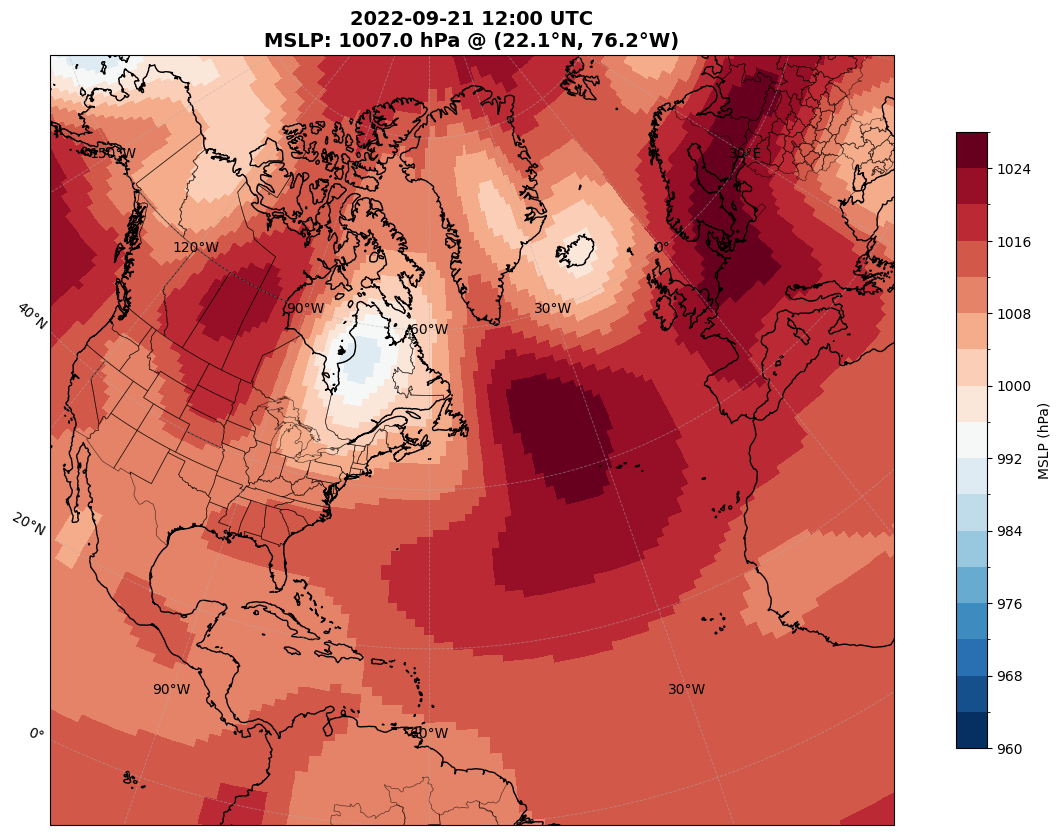

In [ ]:
initial_dataset = Predict_Dataset_Batcher(
    **dataset_params,
    fcst_datetime=forecast_times,
)

initial_loader = BatchForecastLenDataLoader(initial_dataset)

# Initialize FFS with tracking
ffs = HurricaneGenesisFFS(
    model=model,
    state_transformer=Normalize_ERA5_and_Forcing(conf),
    config=conf,
    initial_dataset=initial_dataset,
    dataset_params=dataset_params,
    interfaces=[1000, 988, 980, 975, 970],
    state_A=1008,
    state_B=965,
    output_dir="./ffs_output/newplot",
    rank=0,
    world_size=1,
    worker_id=0,
)

# Enable visualization
ffs.enable_visualization()

# Run FFS (will show live MSLP plots and filter out preexisting storms)
ffs.run_ffs(initial_loader, n_flux_trials=20, n_shoot_trials=10)

# Disable when done
ffs.disable_visualization()